# 04 — Modelo final y evaluación única en test

Este notebook cierra la evaluación **in-domain** sobre RAVDESS Speech. Las decisiones de representación, arquitectura e hiperparámetros ya fueron fijadas mediante outer cross-validation speaker-independent en los notebooks anteriores.

## Protocolo

1. Se audita que `development` y `test_speaker_independent` no compartan archivos ni actores.
2. Las representaciones pueden estar precomputadas para todo el corpus, pero antes del refit solo se materializan matrices y etiquetas de `development`.
3. Cada pipeline se ajusta una sola vez sobre todo `development`.
4. El test se abre después del refit y se predice una única vez.
5. **Balanced accuracy** es la métrica primaria para selección, ordenamiento y comparación.
6. Macro F1, accuracy y métricas por clase se reportan como diagnósticos secundarios.

El modelo SSL final usa `average_mean_std`: promedio uniforme de **13 niveles representacionales** de wav2vec2 —proyección inicial y 12 capas Transformer— seguido por concatenación de media y desvío temporal.

---
## 1 · Configuración

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.contracts import (
    PARTITION_DEVELOPMENT,
    PARTITION_TEST_INDEPENDENT,
    PROTOCOL_INDEPENDENT,
    TARGET_EMOTION_ORIGINAL,
)
from src.evaluation.final_model import (
    audit_speaker_independent_split,
    build_classification_report_table,
    build_cv_test_gap_table,
    compute_actor_metrics,
    compute_quadrant_analysis,
    evaluate_final_pipelines,
    fit_final_pipelines,
    load_cv_reference_table,
    persist_final_artifacts,
    prepare_partition_datasets,
    select_current_oof_predictions,
    validate_expected_labels,
)
from src.experiments.baselines import make_model_factory
from src.features.feature_store import load_representation
from src.features.wav2vec_temporal import (
    build_static_representation,
    extract_or_load_temporal_features,
    load_layer_statistics,
)
from src.models.linear_probe import build_linear_probe
from src.utils.config import get_config, resolve_path
from src.utils.final_model_visualization import (
    plot_actor_domain_comparison,
    plot_cv_test_comparison,
    plot_quadrant_confusion,
    plot_test_confusion_matrices,
)
from src.utils.io import load_metadata, load_splits
from src.utils.reproducibility import set_global_seed

cfg = get_config()
set_global_seed(int(cfg.seed))

PRIMARY_METRIC = str(cfg.metrics.primary)
if PRIMARY_METRIC != "balanced_accuracy":
    raise ValueError(
        "El cierre del proyecto requiere balanced_accuracy como métrica "
        f"principal; config.yaml declara {PRIMARY_METRIC!r}."
    )

REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
FIGURES_DIR = resolve_path(cfg.paths.figures_dir)
MODELS_DIR = resolve_path(cfg.paths.models_dir)
for directory in (REPORTS_DIR, FIGURES_DIR, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

STATS_PATH = resolve_path(
    cfg.temporal_representation.layer_statistics_path
)
SEQUENCES_DIR = resolve_path(
    cfg.temporal_representation.sequences_dir
)

LABELS = list(dict(cfg.emotion_mapping.code_to_name).values())
FINAL_MODEL_NAME = "final_lr_wav2vec_temporal"

print(f"Seed: {cfg.seed}")
print(f"Métrica primaria: {PRIMARY_METRIC}")

Seed: 42
Métrica primaria: balanced_accuracy


---
## 2 · Auditoría de la partición y carga de representaciones

En esta etapa se inspeccionan únicamente la identidad de los archivos, la partición y los actores. Todavía no se construyen matrices ni etiquetas de test.

In [2]:
metadata = load_metadata(cfg.paths.metadata)
splits = load_splits(cfg.paths.splits)

split_audit = audit_speaker_independent_split(
    metadata,
    splits,
    development_partition=PARTITION_DEVELOPMENT,
    test_partition=PARTITION_TEST_INDEPENDENT,
)

display(
    pd.DataFrame(
        [
            {
                "partición": "development",
                "n_audios": split_audit["n_development"],
                "n_actores": split_audit["n_development_actors"],
                "actores": split_audit["development_actors"],
            },
            {
                "partición": "test_speaker_independent",
                "n_audios": split_audit["n_test"],
                "n_actores": split_audit["n_test_actors"],
                "actores": split_audit["test_actors"],
            },
        ]
    )
)

egemaps = load_representation(
    "egemaps",
    cfg.paths.features_dir,
)

temporal_stats = (
    load_layer_statistics(
        STATS_PATH,
        expected_file_ids=metadata["file_id"],
    )
    if STATS_PATH.exists()
    else extract_or_load_temporal_features(
        metadata=metadata,
        statistics_path=STATS_PATH,
        sequences_dir=SEQUENCES_DIR,
        path_col="file_path_trimmed",
        model_name=cfg.features.wav2vec.model_name,
        revision=cfg.features.wav2vec.revision,
        target_sample_rate=int(cfg.audio.target_sample_rate),
        include_feature_projection=bool(
            cfg.temporal_representation.include_feature_projection
        ),
        sequence_dtype=str(
            cfg.temporal_representation.sequence_dtype
        ),
        overwrite=False,
    )
)

WAV2VEC_FINAL_CONFIG = {
    "layer_strategy": "average",
    "pooling": "mean_std",
}
wav2vec_temporal = build_static_representation(
    temporal_stats,
    **WAV2VEC_FINAL_CONFIG,
)

representations = {
    "egemaps": egemaps,
    "wav2vec_temporal": wav2vec_temporal,
}

print(
    f"wav2vec temporal: {temporal_stats.n_files} audios · "
    f"{temporal_stats.n_layers} niveles · "
    f"{temporal_stats.hidden_size} dimensiones ocultas"
)

,partición,n_audios,n_actores,actores
0,development,1200,20,"[1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, ..."
1,test_speaker_independent,240,4,"[2, 6, 21, 23]"


2026-07-05 14:27:55 | INFO     | src.features.feature_store | Cargado 'egemaps': 1440 muestras, 88 features.
wav2vec temporal: 1440 audios · 13 niveles · 768 dimensiones ocultas


La representación temporal se reconstruye con la misma función utilizada durante la validación cruzada. Esto evita que el modelo final implemente una variante accidentalmente distinta de `average_mean_std`.

---
## 3 · Modelos finales fijados por development

In [3]:
FINAL_MODELS = {
    "baseline_rf_egemaps": {
        "label": "Random Forest · eGeMAPSv02",
        "representation": "egemaps",
        "factory": lambda: make_model_factory(
            model_name="random_forest",
            model_config=cfg.models.random_forest,
            seed=int(cfg.seed),
        )(),
    },
    "reference_lr_egemaps": {
        "label": "Logistic Regression · eGeMAPSv02",
        "representation": "egemaps",
        "factory": lambda: build_linear_probe(
            params=dict(cfg.models.logistic_regression),
            seed=int(cfg.seed),
        ),
    },
    FINAL_MODEL_NAME: {
        "label": (
            "Logistic Regression · wav2vec2 "
            "average_mean_std — modelo final"
        ),
        "representation": "wav2vec_temporal",
        "factory": lambda: build_linear_probe(
            params=dict(cfg.models.logistic_regression),
            seed=int(cfg.seed),
        ),
    },
}

display(
    pd.DataFrame(
        [
            {
                "model": key,
                "representación": spec["representation"],
                "descripción": spec["label"],
            }
            for key, spec in FINAL_MODELS.items()
        ]
    )
)

,model,representación,descripción
0,baseline_rf_egemaps,egemaps,Random Forest · eGeMAPSv02
1,reference_lr_egemaps,egemaps,Logistic Regression · eGeMAPSv02
2,final_lr_wav2vec_temporal,wav2vec_temporal,Logistic Regression · wav2vec2 average_mean_st...


---
## 4 · Refit sobre todo development

Las matrices de test todavía no existen en memoria. Cada pipeline usa el 100 % de `development`; el held-out interno ya cumplió su función durante la selección mediante cross-validation.

In [4]:
development_data = prepare_partition_datasets(
    FINAL_MODELS,
    representations,
    metadata,
    splits,
    partition=PARTITION_DEVELOPMENT,
    target_col=TARGET_EMOTION_ORIGINAL,
)

display(
    pd.DataFrame(
        [
            {
                "model": model_name,
                "n_development": dataset.n_samples,
                "n_features": dataset.n_features,
            }
            for model_name, dataset in development_data.items()
        ]
    )
)

fitted_pipelines = fit_final_pipelines(
    FINAL_MODELS,
    development_data,
)
print("Refit final completado sobre development.")

,model,n_development,n_features
0,baseline_rf_egemaps,1200,88
1,reference_lr_egemaps,1200,88
2,final_lr_wav2vec_temporal,1200,1536


Refit final completado sobre development.


---
## 5 · Apertura única del test

A partir de esta celda se materializan por primera vez las matrices y etiquetas de `test_speaker_independent`. No se modifica ningún modelo ni hiperparámetro después de observar estos resultados.

In [5]:
test_data = prepare_partition_datasets(
    FINAL_MODELS,
    representations,
    metadata,
    splits,
    partition=PARTITION_TEST_INDEPENDENT,
    target_col=TARGET_EMOTION_ORIGINAL,
)

validate_expected_labels(
    test_data[FINAL_MODEL_NAME],
    LABELS,
)

test_summary, test_predictions = evaluate_final_pipelines(
    fitted_pipelines,
    FINAL_MODELS,
    test_data,
    labels=LABELS,
)

display(
    test_summary.style.format(
        {
            "balanced_accuracy": "{:.3f}",
            "macro_f1": "{:.3f}",
            "uar": "{:.3f}",
            "weighted_f1": "{:.3f}",
            "accuracy": "{:.3f}",
        }
    )
)

,model,label,representation,n_test,n_features,macro_f1,balanced_accuracy,uar,weighted_f1,accuracy
0,final_lr_wav2vec_temporal,Logistic Regression · wav2vec2 average_mean_std — modelo final,wav2vec_temporal,240,1536,0.809,0.828,0.828,0.812,0.817
1,reference_lr_egemaps,Logistic Regression · eGeMAPSv02,egemaps,240,88,0.540,0.555,0.555,0.539,0.550
2,baseline_rf_egemaps,Random Forest · eGeMAPSv02,egemaps,240,88,0.500,0.523,0.523,0.507,0.525


La tabla anterior es la fuente de verdad del resultado final. El ranking se ordena por **balanced accuracy**. Macro F1 y accuracy ayudan a describir el comportamiento, pero no reemplazan la métrica primaria fijada antes de abrir el test.

---
## 6 · Comparación con outer-CV

,label,cv_mean,cv_std,test_balanced_accuracy,gap_absolute,n_folds
0,Logistic Regression · wav2vec2 average_mean_std — modelo final,0.736,0.049,0.828,+0.092,5
1,Logistic Regression · eGeMAPSv02,0.493,0.069,0.555,+0.062,5
2,Random Forest · eGeMAPSv02,0.472,0.050,0.523,+0.052,5


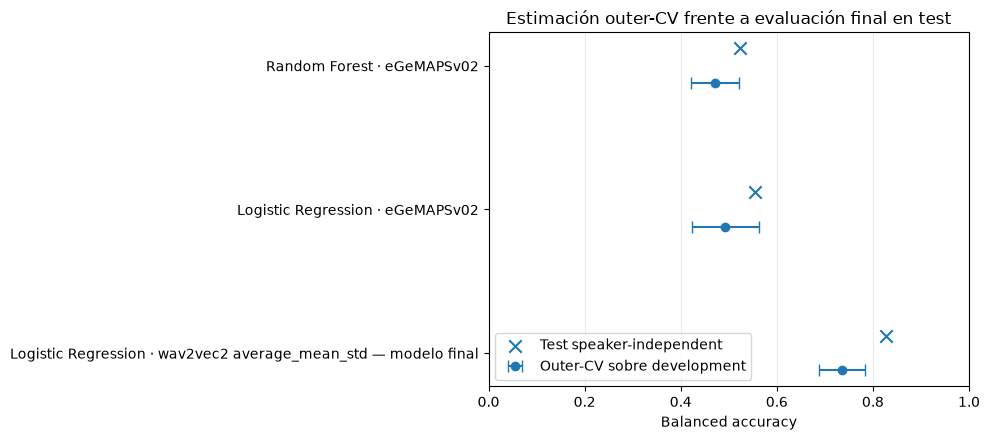

In [6]:
CV_SOURCE_PATHS = {
    "baselines": REPORTS_DIR / "cv_results.csv",
    "temporal": REPORTS_DIR / "temporal_representation_results.csv",
}

CV_REFERENCE_CONFIGS = {
    "baseline_rf_egemaps": {
        "source": "baselines",
        "filters": {
            "representation": "egemaps",
            "protocol": PROTOCOL_INDEPENDENT,
            "target": TARGET_EMOTION_ORIGINAL,
            "model": "random_forest",
            "refinement": "none",
        },
    },
    "reference_lr_egemaps": {
        "source": "baselines",
        "filters": {
            "representation": "egemaps",
            "protocol": PROTOCOL_INDEPENDENT,
            "target": TARGET_EMOTION_ORIGINAL,
            "model": "logistic_regression",
            "refinement": "none",
        },
    },
    FINAL_MODEL_NAME: {
        "source": "temporal",
        "filters": {
            "representation": "wav2vec_temporal",
            "protocol": PROTOCOL_INDEPENDENT,
            "target": TARGET_EMOTION_ORIGINAL,
            "model": "logistic_regression",
            "refinement": "average_mean_std",
            "result_type": "deterministic",
        },
    },
}

cv_reference = load_cv_reference_table(
    CV_SOURCE_PATHS,
    CV_REFERENCE_CONFIGS,
    metric=PRIMARY_METRIC,
)
cv_test_gap = build_cv_test_gap_table(
    cv_reference,
    test_summary,
)

display(
    cv_test_gap[
        [
            "label",
            "cv_mean",
            "cv_std",
            "test_balanced_accuracy",
            "gap_absolute",
            "n_folds",
        ]
    ].style.format(
        {
            "cv_mean": "{:.3f}",
            "cv_std": "{:.3f}",
            "test_balanced_accuracy": "{:.3f}",
            "gap_absolute": "{:+.3f}",
        }
    )
)

fig, _ = plot_cv_test_comparison(cv_test_gap)
fig.savefig(
    FIGURES_DIR / "test_vs_cv_gap.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

El gap CV→test se reporta como diferencia absoluta, no como “cantidad de sigmas”: el desvío entre cinco folds no es un error estándar ni una distribución nula.

Una mejora en test puede combinar dos efectos legítimos:

- el modelo final fue reajustado con todo `development`, mientras que cada modelo outer-CV se entrenó con solo una fracción;
- los actores asignados al test pueden resultar más o menos difíciles que los actores de un fold promedio.

Por eso el test confirma generalización sobre esta partición fija, pero no reemplaza la estimación de variabilidad obtenida mediante speaker-independent CV.

---
## 7 · Diagnóstico por clase

In [7]:
classification_report_final = build_classification_report_table(
    test_predictions,
    model_name=FINAL_MODEL_NAME,
    labels=LABELS,
)

display(classification_report_final)

class_rows = classification_report_final.loc[
    [label for label in LABELS if label in classification_report_final.index]
].copy()

lowest_recall = class_rows["recall"].idxmin()
lowest_precision = class_rows["precision"].idxmin()

print(
    "Menor recall:",
    lowest_recall,
    f"({class_rows.loc[lowest_recall, 'recall']:.3f})",
)
print(
    "Menor precisión:",
    lowest_precision,
    f"({class_rows.loc[lowest_precision, 'precision']:.3f})",
)

,precision,recall,f1-score,support
neutral,0.615,1.000,0.762,16.000
calm,0.722,0.812,0.765,32.000
happy,0.913,0.656,0.764,32.000
sad,1.000,0.500,0.667,32.000
angry,0.933,0.875,0.903,32.000
fearful,0.903,0.875,0.889,32.000
disgust,0.853,0.906,0.879,32.000
surprised,0.727,1.000,0.842,32.000
accuracy,0.817,0.817,0.817,0.817
macro avg,0.833,0.828,0.809,240.000


Menor recall: sad (0.500)
Menor precisión: neutral (0.615)


La lectura conjunta de precisión y recall permite separar dos tipos de error:

- **recall bajo con precisión alta**: el modelo subpredice la emoción y deja muchos casos reales fuera;
- **recall alto con precisión baja**: el modelo sobrepredice la emoción y absorbe ejemplos de otras clases.

La interpretación debe apoyarse en la tabla generada, no en cifras escritas manualmente, para mantenerse válida si se regeneran splits o artefactos.

---
## 8 · Matrices de confusión en test

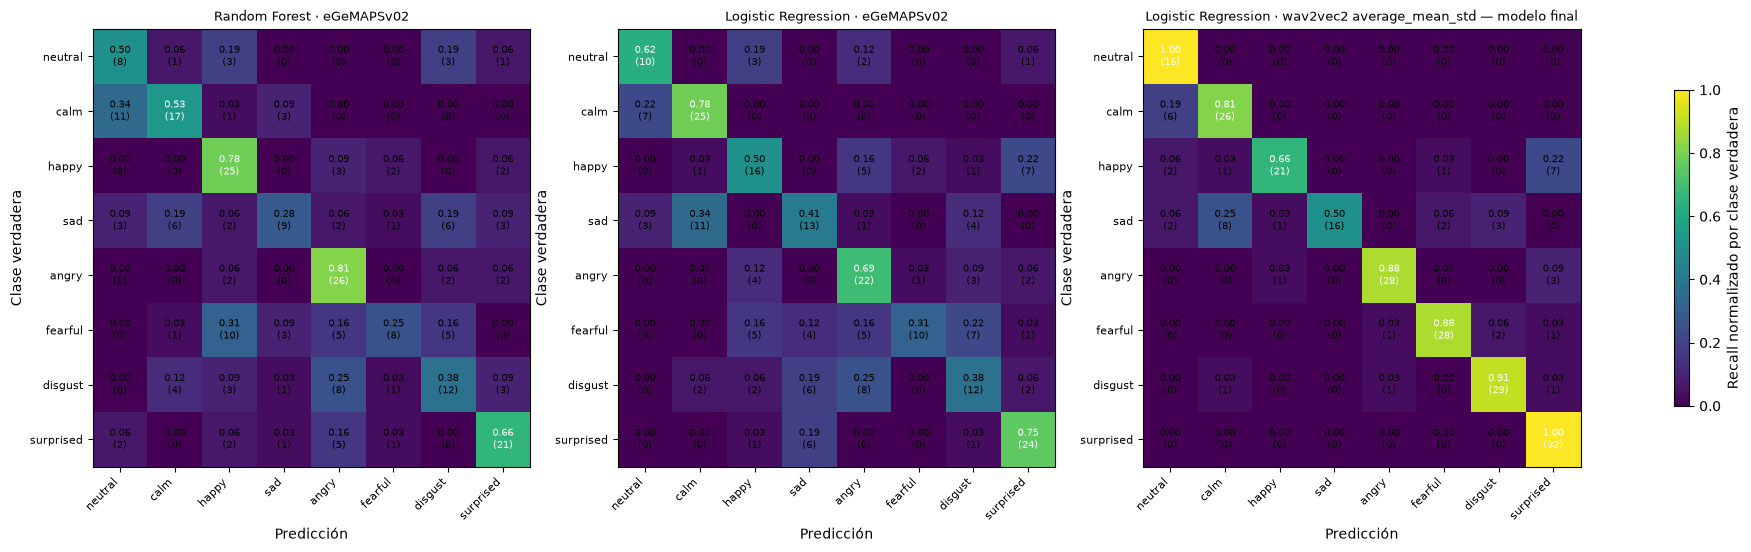

In [8]:
fig, _ = plot_test_confusion_matrices(
    test_predictions,
    FINAL_MODELS,
    labels=LABELS,
)
fig.savefig(
    FIGURES_DIR / "test_confusion_matrices.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

Cada celda muestra el recall normalizado y, entre paréntesis, el número absoluto de audios. Los conteos son importantes porque el test contiene pocos actores y diferencias pequeñas pueden corresponder a pocos ejemplos.

---
## 9 · Proyección a cuadrantes: Q3 frente a Q4

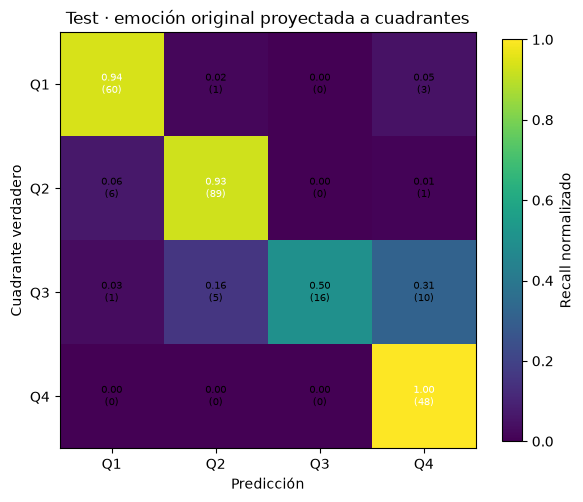

,medida,valor,conteo,denominador
0,Recall Q3,0.500,16,32
1,Q3→Q4 sobre todos los casos Q3,0.312,10,32
2,Q3→Q4 entre los errores de Q3,0.625,10,16


In [9]:
quadrant_predictions, quadrant_metrics = compute_quadrant_analysis(
    test_predictions,
    model_name=FINAL_MODEL_NAME,
)

fig, _ = plot_quadrant_confusion(quadrant_predictions)
fig.savefig(
    FIGURES_DIR / "test_confusion_quadrants.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

q3 = quadrant_predictions.loc[
    quadrant_predictions["y_true_quadrant"].eq("Q3")
]
q3_errors = q3.loc[
    q3["y_pred_quadrant"].ne("Q3")
]
q3_to_q4 = q3.loc[
    q3["y_pred_quadrant"].eq("Q4")
]

q3_summary = pd.DataFrame(
    [
        {
            "medida": "Recall Q3",
            "valor": (
                q3["y_pred_quadrant"].eq("Q3").mean()
            ),
            "conteo": int(
                q3["y_pred_quadrant"].eq("Q3").sum()
            ),
            "denominador": int(len(q3)),
        },
        {
            "medida": "Q3→Q4 sobre todos los casos Q3",
            "valor": len(q3_to_q4) / len(q3),
            "conteo": int(len(q3_to_q4)),
            "denominador": int(len(q3)),
        },
        {
            "medida": "Q3→Q4 entre los errores de Q3",
            "valor": (
                len(q3_to_q4) / len(q3_errors)
                if len(q3_errors)
                else 0.0
            ),
            "conteo": int(len(q3_to_q4)),
            "denominador": int(len(q3_errors)),
        },
    ]
)

display(q3_summary.style.format({"valor": "{:.3f}"}))

La tabla distingue dos denominadores que no deben confundirse:

- la proporción Q3→Q4 sobre **todos** los casos de Q3;
- la proporción Q3→Q4 únicamente entre los **errores** de Q3.

La persistencia de confusiones entre `sad` y `calm/neutral` muestra que el pipeline actual no resolvió completamente la discriminación de valence dentro de regiones de bajo arousal. No demuestra que la información acústica sea insuficiente en términos absolutos: también intervienen el tamaño del corpus, el carácter actuado, el pooling global y la capacidad del clasificador.

---
## 10 · Variabilidad por actor usando el mismo modelo

,actor_id,n_samples,macro_f1,balanced_accuracy,uar,weighted_f1,accuracy
3,23,60,0.613,0.672,0.671875,0.612654,0.650
2,21,60,0.836,0.844,0.843750,0.832754,0.833
1,6,60,0.833,0.859,0.859375,0.828998,0.850
0,2,60,0.924,0.938,0.937500,0.937215,0.933


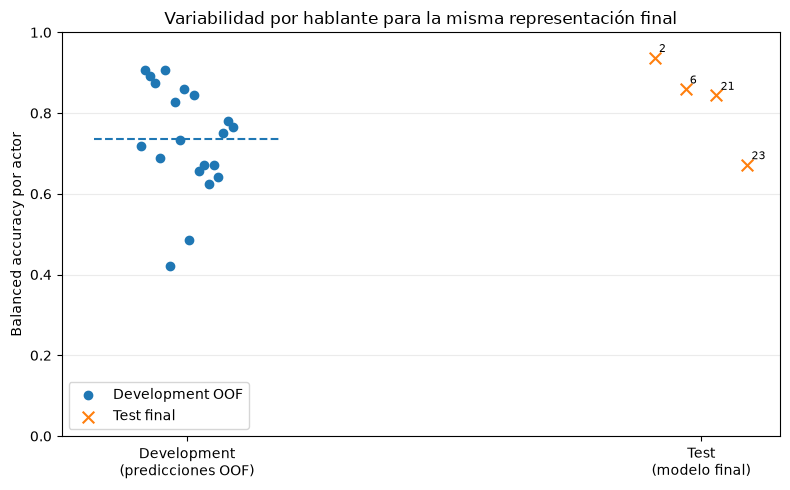

In [10]:
test_actor_metrics = compute_actor_metrics(
    test_predictions,
    model_name=FINAL_MODEL_NAME,
    labels=LABELS,
)

development_actor_metrics = pd.DataFrame()
development_oof_path = REPORTS_DIR / "temporal_oof_predictions.csv"

if development_oof_path.exists():
    development_oof = select_current_oof_predictions(
        development_oof_path,
        filters={
            "representation": "wav2vec_temporal",
            "protocol": PROTOCOL_INDEPENDENT,
            "target": TARGET_EMOTION_ORIGINAL,
            "model": "logistic_regression",
            "refinement": "average_mean_std",
        },
        splits=splits,
        fold_column="fold_speaker_independent",
        development_partition=PARTITION_DEVELOPMENT,
    )
    actor_lookup = metadata[
        ["file_id", "actor_id"]
    ].copy()
    actor_lookup["file_id"] = actor_lookup["file_id"].astype(str)
    development_oof = development_oof.merge(
        actor_lookup,
        on="file_id",
        how="left",
        validate="one_to_one",
    )
    development_actor_metrics = compute_actor_metrics(
        development_oof,
        labels=LABELS,
    )
else:
    print(
        "No existe temporal_oof_predictions.csv; "
        "se mostrará solo el test."
    )

display(
    test_actor_metrics.sort_values("balanced_accuracy").style.format(
        {
            "balanced_accuracy": "{:.3f}",
            "macro_f1": "{:.3f}",
            "accuracy": "{:.3f}",
        }
    )
)

fig, _ = plot_actor_domain_comparison(
    development_actor_metrics,
    test_actor_metrics,
)
fig.savefig(
    FIGURES_DIR / "actor_variability_development_vs_test.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

La comparación actor-level utiliza exactamente `average_mean_std + Logistic Regression` en ambos lados:

- predicciones OOF para los actores de development;
- predicciones del pipeline reajustado para los actores de test.

Aun así, el rendimiento individual mezcla la dificultad propia del hablante con la variación del modelo entrenado en cada outer fold. Debe leerse como diagnóstico descriptivo de heterogeneidad, no como una estimación causal del “efecto actor”.

---
## 11 · Persistencia del modelo y trazabilidad

In [ ]:
final_test_row = (
    test_summary.loc[
        test_summary["model"].eq(FINAL_MODEL_NAME)
    ]
    .iloc[0]
    .to_dict()
)

manifest = {
    "model_name": FINAL_MODEL_NAME,
    "model_label": FINAL_MODELS[FINAL_MODEL_NAME]["label"],
    "primary_metric": PRIMARY_METRIC,
    "selection_protocol": "outer speaker-independent cross-validation",
    "test_protocol": PARTITION_TEST_INDEPENDENT,
    "target": TARGET_EMOTION_ORIGINAL,
    "representation": "wav2vec_temporal",
    "representation_config": WAV2VEC_FINAL_CONFIG,
    "wav2vec_model_name": str(cfg.features.wav2vec.model_name),
    "wav2vec_revision": str(cfg.features.wav2vec.revision),
    "include_feature_projection": bool(
        cfg.temporal_representation.include_feature_projection
    ),
    "n_levels": int(temporal_stats.n_layers),
    "hidden_size": int(temporal_stats.hidden_size),
    "n_features": int(
        development_data[FINAL_MODEL_NAME].n_features
    ),
    "n_development": int(split_audit["n_development"]),
    "n_test": int(split_audit["n_test"]),
    "development_actors": split_audit["development_actors"],
    "test_actors": split_audit["test_actors"],
    "seed": int(cfg.seed),
    "test_metrics": {
        key: value
        for key, value in final_test_row.items()
        if key in {
            "balanced_accuracy",
            "macro_f1",
            "uar",
            "weighted_f1",
            "accuracy",
        }
    },
}

artifact_paths = persist_final_artifacts(
    summary=test_summary,
    predictions=test_predictions,
    classification_report=classification_report_final,
    final_pipeline=fitted_pipelines[FINAL_MODEL_NAME],
    manifest=manifest,
    reports_dir=REPORTS_DIR,
    models_dir=MODELS_DIR,
    final_model_name=FINAL_MODEL_NAME,
)

display(
    pd.DataFrame(
        [
            {"artefacto": name, "ruta": path.as_posix()}
            for name, path in artifact_paths.items()
        ]
    )
)

,artefacto,ruta
0,summary,C:/Users/alega/OneDrive/Documentos/std/Speech_...
1,predictions,C:/Users/alega/OneDrive/Documentos/std/Speech_...
2,classification_report,C:/Users/alega/OneDrive/Documentos/std/Speech_...
3,pipeline,C:/Users/alega/OneDrive/Documentos/std/Speech_...
4,feature_names,C:/Users/alega/OneDrive/Documentos/std/Speech_...
5,manifest,C:/Users/alega/OneDrive/Documentos/std/Speech_...


## 12 · Conclusión

El resultado principal del proyecto es el rendimiento de `Logistic Regression` sobre la representación wav2vec2 temporal `average_mean_std`, evaluado una sola vez sobre actores no vistos. La cifra que gobierna la conclusión es **balanced accuracy**; las demás métricas describen aspectos complementarios.

El cierre debe distinguir tres afirmaciones:

1. **Selección:** el modelo fue elegido únicamente con development y outer-CV speaker-independent.
2. **Generalización in-domain:** el test confirma el comportamiento sobre otra muestra de actores RAVDESS Speech.
3. **Límite del alcance:** este resultado todavía no demuestra generalización a canto, otro idioma, otro corpus ni condiciones acústicas diferentes.

La expansión hacia RAVDESS Song y EMO-DB se aborda después de congelar este cierre, mediante un protocolo de domain shift y transfer learning independiente.

> El test speaker-independent demuestra generalización sobre los cuatro actores reservados. Dado el tamaño reducido de esta partición y la heterogeneidad observada entre hablantes, la balanced accuracy obtenida no debe interpretarse como una estimación precisa del rendimiento sobre toda la población de hablantes posibles; la variabilidad entre folds de development complementa esa estimación.
